# Energy relaxation time $T_1$

In [1]:
from pathlib import Path

import numpy as np

from qblox_lab.config.hardware import create_hardware_agent
from qblox_lab.config.sessions import CONFIG_DIR, SESSIONS
from qblox_lab.config.session_paths import save_config_snapshot, save_result_figures
from qblox_lab.experiments.cal11_energy_relaxation import EnergyRelaxation

## Run parameters

In [2]:
SESSION = SESSIONS["AS_QRC"]
HARDWARE_CONFIG = SESSION.hardware_config
DEVICE_CONFIG = SESSION.device_config
FLUX_CONFIG = SESSION.flux_config  # If None, leave the existing hardware flux unchanged
OUTPUT_DIR = SESSION.output_dir
EXPERIMENT_NAME = "energy_relaxation"

QUBITS = ["q1"]
DELAYS = np.arange(start=0.1, stop=100, step=0.5) * 1e-6
REPETITIONS = 300
RESET_TYPE = "thermal"  # "thermal" or "active" (ConditionalReset)

READOUT_AMPLITUDE = None
DRIVE_OUTPUT_ATTENUATION = None
READOUT_OUTPUT_ATTENUATION = None
READOUT_INPUT_ATTENUATION = None
TIMEOUT = 300
CREATE_DUMMY_CONNECTIONS = False

PLOT_RESULTS = True

## Hardware and experiment

In [3]:
import atexit

from qcodes.instrument import Instrument

hardware_agent = create_hardware_agent(
    hardware_configuration=HARDWARE_CONFIG,
    device_configuration=DEVICE_CONFIG,
    output_dir=OUTPUT_DIR,
    create_dummy_connections=CREATE_DUMMY_CONNECTIONS,
)

experiment = EnergyRelaxation(
    hardware_agent=hardware_agent,
    qubits=QUBITS,
    flux_config=FLUX_CONFIG,
)

atexit.register(Instrument.close_all)

<bound method Instrument.close_all of <class 'qcodes.instrument.instrument.Instrument'>>

## Measurement

In [4]:
dataset = experiment.run_measurement(
    delays=DELAYS,
    repetitions=REPETITIONS,
    reset_type=RESET_TYPE,
    readout_amplitude=READOUT_AMPLITUDE,
    drive_output_attenuation=DRIVE_OUTPUT_ATTENUATION,
    readout_output_attenuation=READOUT_OUTPUT_ATTENUATION,
    readout_input_attenuation=READOUT_INPUT_ATTENUATION,
    timeout=TIMEOUT,
)
dataset

/home/reny871224/micromamba/envs/qblox-training/lib/python3.10/site-packages/qblox_scheduler/backends/qblox/compiler_abc.py:285: UserWarning: Exact capabilities for ISA version 2.1 not found, using capabilities for version 2.2.
  warnings.warn(


<xarray.Dataset> Size: 6kB
Dimensions:           (acq_index_S21_q1: 200)
Coordinates:
    delay_q1          (acq_index_S21_q1) float64 2kB 1e-07 6e-07 ... 9.96e-05
  * acq_index_S21_q1  (acq_index_S21_q1) int64 2kB 0 1 2 3 4 ... 196 197 198 199
Data variables:
    S21_q1            (acq_index_S21_q1) complex128 3kB (-0.00090506078958511...
Attributes:
    tuid:     20260915-145141-238-d23dd1

## Optional: Simulated data

In [5]:
# dataset = experiment.simulated_data(
#     delays=DELAYS,
#     repetitions=REPETITIONS,
#     t1=100e-6,
#     noise=0.002,
#     seed=42,
# )

## Analysis

In [6]:
results = experiment.analysis()
for qubit, result in results.items():
    if result.success:
        print(f"{qubit}: T1 = {result.t1 / 1e-6:.3f} us")
    else:
        print(f"{qubit}: T1 fit failed")

q1: T1 = 16.095 us


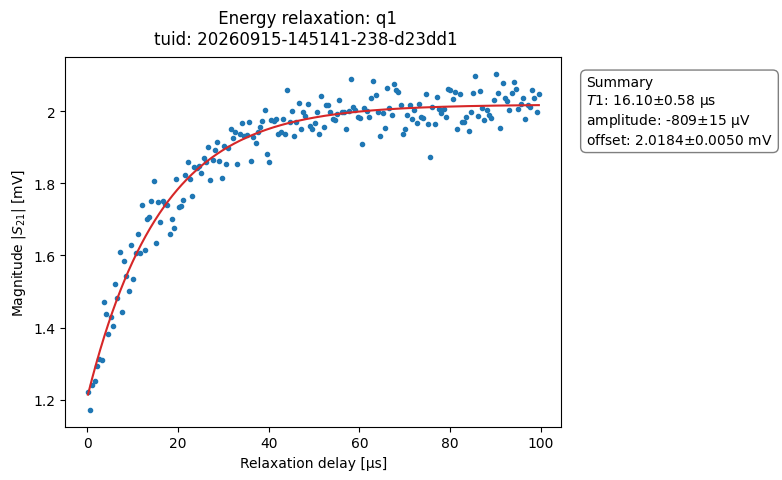

In [7]:
if PLOT_RESULTS:
    experiment.plot()

In [ ]:
if PLOT_RESULTS and experiment.figures:
    save_result_figures(SESSION, dataset, EXPERIMENT_NAME, experiment.figures)
save_config_snapshot(SESSION, dataset, EXPERIMENT_NAME)


## Release hardware connection

In [ ]:
from qcodes.instrument import Instrument

Instrument.close_all()